# Model 2C, Gaussian Naive Bayes Experiment 01

This append-only experiment tests Gaussian Naive Bayes for Model 2C. It holds Logistic Regression 2C Experiment 02's selected representation fixed: 31 raw-taxi source fields plus a fold-fitted spline of `MINUTES_TO_SCHEDULED_ARRIVAL = CRSElapsedTime - DepDelay - TaxiOut`.

The experiment changes only the classifier. It selects variance smoothing using five expanding 2019 folds, refits the selected design on all 2019 rows, and evaluates it once on 2023. Imputation, category encoding, scaling, spline knots, classifier settings, and the operating threshold are learned from 2019 only. No new feature dataset is created, and the 2024 dataset is not loaded.


In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    make_scorer,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler

AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "ArrDel15"
N_TIME_SPLITS = 5
N_JOBS = 1
SPLINE_KNOTS = 5
SPLINE_DEGREE = 3

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


## Load and validate the shared arrival datasets

The experiment uses the same 2019 training rows and 2023 validation rows as the completed Model 2C experiments.


In [2]:
def find_project_root(start: Path, airport: str, years) -> Path:
    required = [
        Path("data/features") / f"{airport}_{year}_arrivals.csv"
        for year in years
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required feature datasets: {required}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve(), AIRPORT, [TRAIN_YEAR, VALIDATION_YEAR])
TRAIN_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{TRAIN_YEAR}_arrivals.csv"
VALIDATION_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{VALIDATION_YEAR}_arrivals.csv"

train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_DATA_PATH, low_memory=False)


def validate_source_frame(frame: pd.DataFrame, year: int, partition: str):
    required = {"FlightDate", "Dest", TARGET}
    missing = sorted(required.difference(frame.columns))
    assert not missing, f"{partition} missing columns: {missing}"
    frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="raise")
    assert frame["FlightDate"].dt.year.eq(year).all()
    assert frame["Dest"].eq(AIRPORT).all()
    assert frame[TARGET].notna().all()
    assert set(frame[TARGET].unique()).issubset({0, 0.0, 1, 1.0})
    return {
        "partition": partition,
        "year": year,
        "start": frame["FlightDate"].min().date(),
        "end": frame["FlightDate"].max().date(),
        "days": frame["FlightDate"].dt.normalize().nunique(),
        "rows": len(frame),
        "delayed_flights": int(frame[TARGET].sum()),
        "delay_rate": frame[TARGET].mean(),
    }


source_summary = pd.DataFrame([
    validate_source_frame(train_df, TRAIN_YEAR, "training"),
    validate_source_frame(validation_df, VALIDATION_YEAR, "external validation"),
]).set_index("partition")
source_summary

,year,start,end,days,rows,delayed_flights,delay_rate
partition,,,,,,,
training,2019,2019-01-01,2019-12-31,365,107354,21784,0.2029
external validation,2023,2023-01-01,2023-12-31,365,109947,27077,0.2463


## Hold the selected Model 2C representation fixed

All 31 source fields and the degree-3 schedule-margin spline match Logistic Regression 2C Experiment 02. Gaussian Naive Bayes is the only substantive model change.


In [3]:
CATEGORICAL_FEATURES = ["Reporting_Airline", "Origin"]

MODEL_2A_NUMERIC_FEATURES = [
    "SCHED_DEP_TIME_SIN",
    "SCHED_DEP_TIME_COS",
    "SCHED_ARR_TIME_SIN",
    "SCHED_ARR_TIME_COS",
    "DAY_OF_WEEK_SIN",
    "DAY_OF_WEEK_COS",
    "DAY_OF_YEAR_SIN",
    "DAY_OF_YEAR_COS",
    "IS_WEEKEND",
    "CRSElapsedTime",
    "LOG_DISTANCE",
    "SCHEDULED_SPEED_PROXY",
    "ASPM_THREE_HOUR_SCHEDULED_DEPARTURES",
    "ASPM_THREE_HOUR_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_MINUS_PREVIOUS_TRAFFIC",
    "ASPM_NEXT_MINUS_CURRENT_TRAFFIC",
    "ASPM_MAX_HOURLY_TRAFFIC",
    "HourlyDryBulbTemperature",
    "TEMP_DEWPOINT_SPREAD",
    "LOG_PRECIPITATION",
    "HourlyVisibility",
    "WindX",
    "WindY",
    "ADVERSE_WEATHER",
    "NOAA_AGE_MINUTES",
]
NUMERIC_FEATURES = [
    *MODEL_2A_NUMERIC_FEATURES,
    "DepDelay",
    "TaxiOut",
    "ACTUAL_TAKEOFF_TIME_SIN",
    "ACTUAL_TAKEOFF_TIME_COS",
]
CALCULATED_MARGIN = "MINUTES_TO_SCHEDULED_ARRIVAL"
SOURCE_FEATURES = [*CATEGORICAL_FEATURES, *NUMERIC_FEATURES]
MODEL_COLUMNS = [*SOURCE_FEATURES, CALCULATED_MARGIN]

assert len(SOURCE_FEATURES) == len(set(SOURCE_FEATURES)) == 31
assert len(MODEL_COLUMNS) == 32

required_columns = ["FlightDate", "Dest", "CRSDepTime", TARGET, *SOURCE_FEATURES]
for partition, frame in [("training", train_df), ("external validation", validation_df)]:
    missing = sorted(set(required_columns).difference(frame.columns))
    assert not missing, f"{partition} missing required columns: {missing}"

forbidden_predictors = {
    TARGET,
    "DepTime",
    "DepDelayMinutes",
    "DepDel15",
    "DepartureDelayGroups",
    "WheelsOff",
    "ArrTime",
    "ArrDelay",
    "ArrDelayMinutes",
    "ArrivalDelayGroups",
    "WheelsOn",
    "TaxiIn",
    "ActualElapsedTime",
    "AirTime",
    "Tail_Number",
}
assert not forbidden_predictors.intersection(SOURCE_FEATURES)

pd.Series({
    "saved source fields": len(SOURCE_FEATURES),
    "calculated model-side fields": 1,
    "model inputs before preprocessing": len(MODEL_COLUMNS),
    "categorical source fields": len(CATEGORICAL_FEATURES),
    "numeric source fields": len(NUMERIC_FEATURES),
}, name="Gaussian Naive Bayes 2C input design").to_frame()


,Gaussian Naive Bayes 2C input design
saved source fields,31
calculated model-side fields,1
model inputs before preprocessing,32
categorical source fields,2
numeric source fields,29


## Calculate the margin and create chronological folds

The row-level margin uses only information known at takeoff. Every learned transformation is fitted separately inside each 2019 training fold.


In [4]:
def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)
    for column in CATEGORICAL_FEATURES:
        frame[column] = frame[column].astype(object)
    for column in NUMERIC_FEATURES:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    frame[CALCULATED_MARGIN] = (
        frame["CRSElapsedTime"] - frame["DepDelay"] - frame["TaxiOut"]
    )
    return frame


train_model_df = prepare_model_frame(train_df)
validation_model_df = prepare_model_frame(validation_df)
X_train = train_model_df[MODEL_COLUMNS].reset_index(drop=True)
X_validation = validation_model_df[MODEL_COLUMNS].reset_index(drop=True)
y_train = train_model_df[TARGET].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)

assert training_dates.max() < validation_dates.min()
assert X_train[CALCULATED_MARGIN].notna().all()
assert X_validation[CALCULATED_MARGIN].notna().all()


def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    unique_days = np.array(sorted(pd.unique(normalized)))
    day_blocks = np.array_split(unique_days, n_splits + 1)
    splits, rows = [], []
    for fold in range(1, n_splits + 1):
        train_days = np.concatenate(day_blocks[:fold])
        heldout_days = day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold,
            "train_rows": len(train_idx),
            "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })
    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(
    training_dates, y_train, N_TIME_SPLITS
)
display(pd.DataFrame({
    "training": X_train[CALCULATED_MARGIN].describe(),
    "external_validation": X_validation[CALCULATED_MARGIN].describe(),
}))
fold_summary

,training,external_validation
count,"107,354.0000","109,947.0000"
mean,178.5130,165.9134
std,113.4119,117.9957
min,"-1,392.0000","-2,266.0000"
25%,97.0000,94.0000
50%,161.0000,148.0000
75%,288.0000,264.0000
max,578.0000,601.0000


,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17776,18725,2019-03-02,2019-03-03,2019-05-02,0.2082,0.1834
2,36501,18153,2019-05-02,2019-05-03,2019-07-02,0.1955,0.2319
3,54654,17703,2019-07-02,2019-07-03,2019-09-01,0.2076,0.2646
4,72357,17650,2019-09-01,2019-09-02,2019-11-01,0.2215,0.1474
5,90007,17347,2019-11-01,2019-11-02,2019-12-31,0.2070,0.1818


## Select variance smoothing using 2019

Gaussian Naive Bayes estimates a separate mean and variance for each prepared predictor within each outcome class. `var_smoothing` adds stability when a predictor has very little within-class variance. Twelve values are compared using mean temporal average precision.


In [5]:
def make_pipeline():
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ])
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])
    margin_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        (
            "spline",
            SplineTransformer(
                n_knots=SPLINE_KNOTS,
                degree=SPLINE_DEGREE,
                knots="quantile",
                extrapolation="linear",
                include_bias=False,
            ),
        ),
        ("scaler", StandardScaler()),
    ])
    preprocessor = ColumnTransformer(
        [
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("schedule_margin", margin_pipeline, [CALCULATED_MARGIN]),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )
    return Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", GaussianNB()),
    ])


parameter_grid = {
    "classifier__var_smoothing": np.logspace(-12, -1, 12),
}
scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": "recall",
    "f1": "f1",
    "mcc": make_scorer(matthews_corrcoef),
    "neg_brier": "neg_brier_score",
}

search_start = perf_counter()
search = GridSearchCV(
    estimator=make_pipeline(),
    param_grid=parameter_grid,
    scoring=scoring,
    refit="average_precision",
    cv=temporal_splits,
    n_jobs=N_JOBS,
    pre_dispatch=N_JOBS,
    verbose=0,
    return_train_score=False,
    error_score="raise",
)
search.fit(X_train, y_train)
search_seconds = perf_counter() - search_start
best_pipeline = search.best_estimator_
search_results = pd.DataFrame(search.cv_results_)

display_columns = [
    "param_classifier__var_smoothing",
    "mean_test_average_precision",
    "std_test_average_precision",
    "mean_test_roc_auc",
    "mean_test_neg_brier",
    "mean_fit_time",
]
ranked_search_results = (
    search_results[display_columns]
    .assign(mean_brier_score=lambda frame: -frame["mean_test_neg_brier"])
    .drop(columns="mean_test_neg_brier")
    .sort_values(
        ["mean_test_average_precision", "mean_test_roc_auc"],
        ascending=False,
    )
    .reset_index(drop=True)
)

print(f"Gaussian NB search completed in {search_seconds:,.1f} seconds")
print(f"Best mean temporal-validation AP: {search.best_score_:.4f}")
print(f"Selected parameters: {search.best_params_}")
ranked_search_results


Gaussian NB search completed in 11.8 seconds
Best mean temporal-validation AP: 0.7937
Selected parameters: {'classifier__var_smoothing': np.float64(0.01)}


,param_classifier__var_smoothing,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,mean_fit_time,mean_brier_score
0,0.0100,0.7937,0.0419,0.8811,0.1426,0.7025
1,0.0010,0.7398,0.0610,0.8692,0.1416,0.7601
2,0.1000,0.7283,0.0601,0.8552,0.1447,0.4007
3,0.0001,0.6228,0.0803,0.8509,0.1405,0.7751
4,0.0000,0.3862,0.0827,0.7668,0.1379,0.7801
5,0.0000,0.2437,0.0510,0.6033,0.1384,0.7850
6,0.0000,0.2105,0.0444,0.5251,0.1390,0.7874
7,0.0000,0.2055,0.0425,0.5109,0.1431,0.7883
8,0.0000,0.2046,0.0426,0.5082,0.1379,0.7884
9,0.0000,0.2038,0.0420,0.5059,0.1382,0.7892


## Select the operating threshold using 2019 only

The selected smoothing configuration is refitted once per chronological fold. The exact thresholds returned by the 2019 precision–recall curve are ranked by F1, with precision as the tie-breaker. This avoids imposing a narrow threshold grid on Naive Bayes probabilities, which may be less well calibrated than logistic-regression probabilities.


In [6]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


oof_probabilities = np.full(len(y_train), np.nan)
for train_idx, heldout_idx in temporal_splits:
    fold_model = clone(best_pipeline)
    fold_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    oof_probabilities[heldout_idx] = fold_model.predict_proba(
        X_train.iloc[heldout_idx]
    )[:, 1]

oof_mask = np.isfinite(oof_probabilities)
oof_y = y_train.to_numpy()[oof_mask]
oof_p = oof_probabilities[oof_mask]
curve_precision, curve_recall, curve_thresholds = precision_recall_curve(
    oof_y, oof_p
)
threshold_results = pd.DataFrame({
    "threshold": curve_thresholds,
    "precision": curve_precision[:-1],
    "recall": curve_recall[:-1],
})
threshold_results["f1"] = np.divide(
    2 * threshold_results["precision"] * threshold_results["recall"],
    threshold_results["precision"] + threshold_results["recall"],
    out=np.zeros(len(threshold_results)),
    where=(
        threshold_results["precision"] + threshold_results["recall"]
    ).to_numpy() > 0,
)
selected_threshold = float(
    threshold_results.sort_values(
        ["f1", "precision"], ascending=False
    ).iloc[0]["threshold"]
)

print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Training-only selected threshold: {selected_threshold:.8f}")
threshold_results.sort_values(
    ["f1", "precision"], ascending=False
).head(10)


Threshold-selection rows: 89,578
Training-only selected threshold: 0.99999996


,threshold,precision,recall,f1
75147,1.0000,0.8451,0.6727,0.7491
75146,1.0000,0.8451,0.6727,0.7491
75148,1.0000,0.8451,0.6727,0.7491
75145,1.0000,0.8450,0.6727,0.7491
75153,1.0000,0.8453,0.6726,0.7491
75150,1.0000,0.8452,0.6726,0.7491
75144,1.0000,0.8450,0.6727,0.7491
75152,1.0000,0.8452,0.6726,0.7491
75149,1.0000,0.8451,0.6726,0.7491
75154,1.0000,0.8453,0.6725,0.7491


## Refit the selected Gaussian Naive Bayes model on 2019 and evaluate 2023

Only the smoothing value selected on 2019 is evaluated on 2023. Logistic Regression 2C-02 is a fixed documented comparison and is not refitted here.


In [7]:
final_fit_start = perf_counter()
best_pipeline.fit(X_train, y_train)
final_fit_seconds = perf_counter() - final_fit_start
validation_probabilities = best_pipeline.predict_proba(X_validation)[:, 1]

evaluation_results = pd.DataFrame([
    {
        "model": "Logistic Regression 2C-02 (documented)",
        "threshold": 0.45,
        "accuracy": 0.9239,
        "balanced_accuracy": 0.8712,
        "precision": 0.9098,
        "recall": 0.7672,
        "f1": 0.8324,
        "mcc": 0.7885,
        "roc_auc": 0.9491,
        "average_precision": 0.9145,
        "brier_score": 0.0594,
    },
    {
        "model": "Gaussian Naive Bayes 2C-01 (default)",
        **evaluate_probabilities(y_validation, validation_probabilities, 0.50),
    },
    {
        "model": "Gaussian Naive Bayes 2C-01 (training-selected)",
        **evaluate_probabilities(
            y_validation, validation_probabilities, selected_threshold
        ),
    },
]).set_index("model")

print(f"Final all-2019 fit completed in {final_fit_seconds:,.1f} seconds")
evaluation_results


Final all-2019 fit completed in 0.3 seconds


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
Logistic Regression 2C-02 (documented),0.4500,0.9239,0.8712,0.9098,0.7672,0.8324,0.7885,0.9491,0.9145,0.0594
Gaussian Naive Bayes 2C-01 (default),0.5000,0.7245,0.7698,0.4677,0.8590,0.6056,0.4670,0.8867,0.8282,0.2226
Gaussian Naive Bayes 2C-01 (training-selected),1.0000,0.8700,0.7415,0.9675,0.4883,0.6491,0.6307,0.8867,0.8282,0.2226


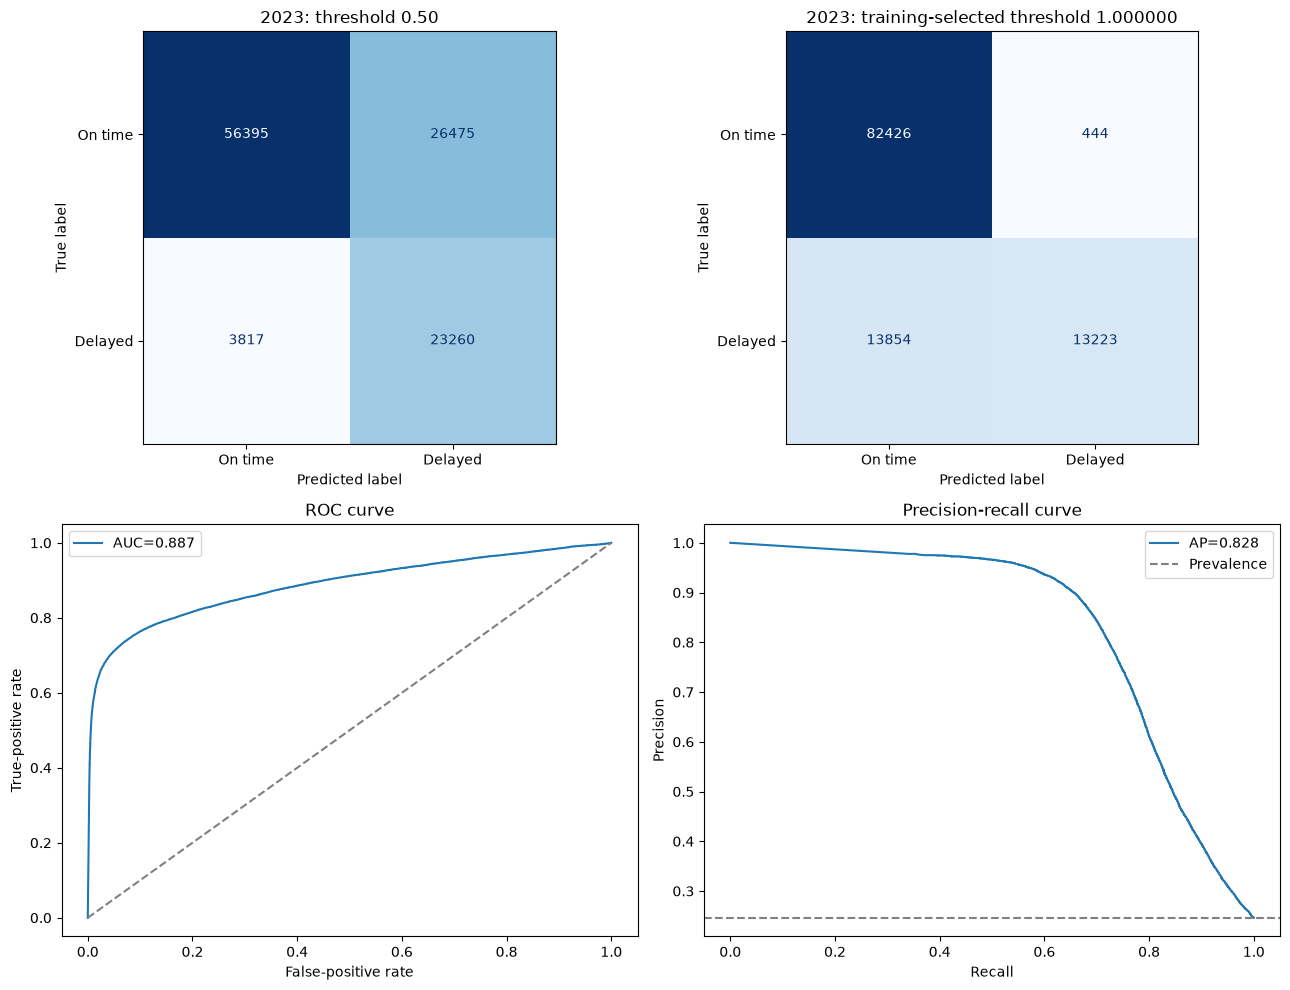

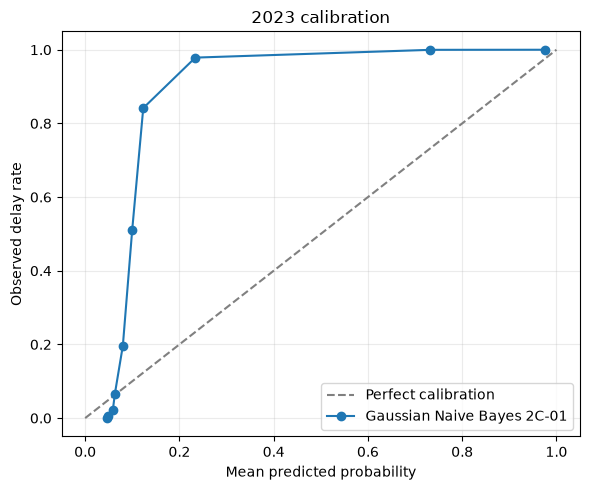

In [8]:
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_validation, validation_probabilities
)
curve_precision, curve_recall, _ = precision_recall_curve(
    y_validation, validation_probabilities
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    default_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("2023: threshold 0.50")
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    selected_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title(
    f"2023: training-selected threshold {selected_threshold:.6f}"
)
axes[1, 0].plot(
    false_positive_rate,
    true_positive_rate,
    label=f"AUC={roc_auc_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].set(
    xlabel="False-positive rate",
    ylabel="True-positive rate",
    title="ROC curve",
)
axes[1, 0].legend()
axes[1, 1].plot(
    curve_recall,
    curve_precision,
    label=f"AP={average_precision_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 1].axhline(
    y_validation.mean(), linestyle="--", color="gray", label="Prevalence"
)
axes[1, 1].set(
    xlabel="Recall",
    ylabel="Precision",
    title="Precision-recall curve",
)
axes[1, 1].legend()
fig.tight_layout()
plt.show()

predicted, observed = calibration_curve(
    y_validation, validation_probabilities, n_bins=10, strategy="quantile"
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(predicted, observed, marker="o", label="Gaussian Naive Bayes 2C-01")
ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed delay rate",
    title="2023 calibration",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Inspect fitted distributions and publishable values

Gaussian Naive Bayes estimates one mean and variance per prepared predictor and outcome class. The standardized mean gap below is a descriptive check of which prepared values separate the classes most strongly under this model. It is not a causal importance measure, and it does not account for correlation among predictors.


In [9]:
preprocessor = best_pipeline.named_steps["preprocessor"]
classifier = best_pipeline.named_steps["classifier"]
prepared_feature_names = preprocessor.get_feature_names_out()
pooled_scale = np.sqrt((classifier.var_[0] + classifier.var_[1]) / 2.0)
distribution_table = (
    pd.DataFrame({
        "feature": prepared_feature_names,
        "on_time_mean": classifier.theta_[0],
        "delayed_mean": classifier.theta_[1],
        "standardized_mean_gap": np.abs(
            classifier.theta_[1] - classifier.theta_[0]
        ) / pooled_scale,
    })
    .sort_values("standardized_mean_gap", ascending=False)
    .reset_index(drop=True)
)
display(distribution_table.head(25))
display(
    distribution_table[
        distribution_table["feature"].str.contains(
            "TaxiOut|MINUTES_TO_SCHEDULED_ARRIVAL", regex=True
        )
    ]
)

default = evaluation_results.loc[
    "Gaussian Naive Bayes 2C-01 (default)"
]
selected = evaluation_results.loc[
    "Gaussian Naive Bayes 2C-01 (training-selected)"
]
publishable_summary = pd.Series({
    "selected representation": "raw_taxi_margin_spline",
    "saved source fields": len(SOURCE_FEATURES),
    "calculated model-side fields": 1,
    "prepared predictors": len(prepared_feature_names),
    "selected var_smoothing": search.best_params_["classifier__var_smoothing"],
    "fitted on-time prior": classifier.class_prior_[0],
    "fitted delayed prior": classifier.class_prior_[1],
    "training CV AP": search.best_score_,
    "validation prevalence": y_validation.mean(),
    "validation AP": default["average_precision"],
    "validation ROC AUC": default["roc_auc"],
    "validation Brier": default["brier_score"],
    "selected threshold": selected_threshold,
    "selected-threshold accuracy": selected["accuracy"],
    "selected-threshold balanced accuracy": selected["balanced_accuracy"],
    "selected-threshold precision": selected["precision"],
    "selected-threshold recall": selected["recall"],
    "selected-threshold F1": selected["f1"],
    "selected-threshold MCC": selected["mcc"],
    "search seconds": search_seconds,
    "final fit seconds": final_fit_seconds,
}, name="Gaussian Naive Bayes 2C Experiment 01 Appendix F values")
publishable_summary.to_frame()


,feature,on_time_mean,delayed_mean,standardized_mean_gap
0,numeric__DepDelay,-0.2761,1.0846,1.0413
1,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,-0.1805,0.7088,0.7620
2,numeric__TaxiOut,-0.1381,0.5426,0.5453
3,numeric__ACTUAL_TAKEOFF_TIME_SIN,0.0940,-0.3693,0.4923
4,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,0.0855,-0.3359,0.4547
5,numeric__SCHED_DEP_TIME_SIN,0.0825,-0.3242,0.4233
6,numeric__SCHED_ARR_TIME_COS,-0.0786,0.3086,0.3885
7,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,-0.1147,0.4504,0.3694
8,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,0.0684,-0.2685,0.3442
9,numeric__SCHED_ARR_TIME_SIN,0.0486,-0.1908,0.2453


,feature,on_time_mean,delayed_mean,standardized_mean_gap
1,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,-0.1805,0.7088,0.7620
2,numeric__TaxiOut,-0.1381,0.5426,0.5453
4,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,0.0855,-0.3359,0.4547
7,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,-0.1147,0.4504,0.3694
8,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,0.0684,-0.2685,0.3442
16,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,-0.0245,0.0961,0.1296
17,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,-0.0411,0.1613,0.1291


,Gaussian Naive Bayes 2C Experiment 01 Appendix F values
selected representation,raw_taxi_margin_spline
saved source fields,31
calculated model-side fields,1
prepared predictors,108
selected var_smoothing,0.0100
fitted on-time prior,0.7971
fitted delayed prior,0.2029
training CV AP,0.7937
validation prevalence,0.2463
validation AP,0.8282


## Interpretation checklist

1. Does Gaussian Naive Bayes improve 2019 temporal average precision over Logistic Regression 2C Experiment 02?
2. Does any training gain persist in 2023 ranking, probability quality, F1, or MCC?
3. Are the predicted probabilities sufficiently calibrated for operational use?
4. Does the conditional-independence assumption appear suitable for these correlated flight, traffic, weather, and spline predictors?
5. Is the difference large enough to replace the sparse L1 model?
6. Keep the existing feature dataset unchanged and keep 2024 untouched.
